# Auto-encodeur à 10 classes

## Configuration du notebook

In [30]:
import zipfile
import tempfile
import pathlib
import struct

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer
from mpl_toolkits.axes_grid1 import make_axes_locatable
import scipy.stats as sp
from scipy.special import expit
import seaborn as sns
import pandas as pd

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

## Extraction des données

In [33]:
def charger_images_mnist(chemin_fichier):
    """Charge un fichier d'images MNIST (.idx3-ubyte) et le prépare pour l'ACP."""
    with open(chemin_fichier, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num_images, rows * cols)
    return images

def charger_labels_mnist(chemin_fichier):
    """Charge un fichier d'étiquettes MNIST (.idx1-ubyte)."""
    with open(chemin_fichier, 'rb') as f:
        magic, num_items = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

In [34]:
chemin_donnees = "../../../../Données/mnist.zip"  # A adapter selon vos besoins
tmp = pathlib.Path(tempfile.gettempdir())
chemin_travail = tmp.joinpath("MNIST")

In [35]:
archive = zipfile.ZipFile(chemin_donnees)
archive.extractall(chemin_travail)

In [36]:
images_train = charger_images_mnist(chemin_travail.joinpath("train-images-idx3-ubyte").joinpath("train-images-idx3-ubyte"))
labels_train = charger_labels_mnist(chemin_travail.joinpath("train-labels-idx1-ubyte").joinpath("train-labels-idx1-ubyte"))
images_train.shape, labels_train.shape

((60000, 784), (60000,))

In [37]:
images_test = charger_images_mnist(chemin_travail.joinpath("t10k-images-idx3-ubyte").joinpath("t10k-images-idx3-ubyte"))
labels_test = charger_labels_mnist(chemin_travail.joinpath("t10k-labels-idx1-ubyte").joinpath("t10k-labels-idx1-ubyte"))
images_test.shape, labels_test.shape

((10000, 784), (10000,))

Normalisation des images:

In [38]:
images_train = images_train / 255.
images_test = images_test / 255.

## Fonctions de visualisation

In [39]:
def visualiser_image(images, labels, index = None, label = None):
    if index is None:
        index = np.random.choice(images.shape[0])
    image = images[index]
    p = image.shape[0]
    image = image.reshape(int(np.sqrt(p)), int(np.sqrt(p)))
    if label is None:
        label = f"{labels[index]}"
    else:
        label = f"{label}: {labels[index]}"
    plt.imshow(image, cmap="gray", vmin=0., vmax=1.)
    plt.axis("off")
    plt.title(label)

In [40]:
def visualiser_image_classification(images, labels, scores, index=None, label=None):
    if index is None:
        index = np.random.choice(images.shape[0])
    image = images[index]
    p = image.shape[0]
    image = image.reshape(int(np.sqrt(p)), int(np.sqrt(p)))
    if label is None:
        label = f"{labels[index]}"
    else:
        label = f"{label}: {labels[index]}"
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.imshow(image, cmap="gray", vmin=0., vmax=1.)
    ax1.axis("off")
    ax1.set_title(f"Index = {index} / Classe vraie = {label}")
    divider = make_axes_locatable(ax1)
    ax2 = divider.append_axes("right", size="100%", pad=0.5)
    probabs = scores[index]
    classe_predite = np.argmax(probabs)
    barres = ax2.barh(range(10), probabs, color="tab:blue")
    barres[classe_predite].set_color("tab:orange")
    ax2.set_yticks(range(10), range(10))
    ax2.set_xlim(0, 1.)
    ax2.set_title("probabilités")

In [41]:
def visualiser_autoencodeur(images, labels, reconstructions, index = None):
    if index is None:
        index = np.random.choice(images.shape[0])
    image = images[index]
    reconstruction = reconstructions[index]
    p = image.shape[0]
    image = image.reshape(int(np.sqrt(p)), int(np.sqrt(p)))
    reconstruction = reconstruction.reshape(int(np.sqrt(p)), int(np.sqrt(p)))
    label = f"{labels[index]}"
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(image, cmap="gray", vmin=0., vmax=1.)
    axes[1].imshow(reconstruction, cmap="gray", vmin=0., vmax=1.)
    axes[0].axis("off")
    axes[0].set_title(f"Index = {index} / Classe vraie = {label}")
    axes[1].axis("off")
    axes[1].set_title(f"Index = {index} / Classe vraie = {label}")    

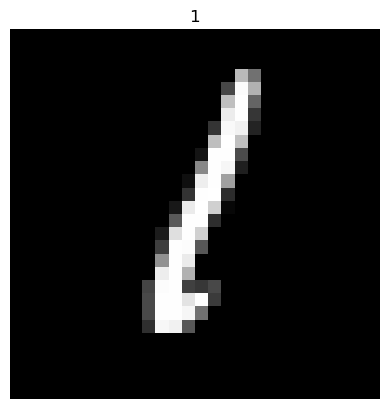

In [42]:
visualiser_image(images_train, labels_train)

## Modules Pytorch

In [52]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),            
            nn.Linear(128, 64),
            nn.ReLU()
        )
        self.mu = nn.Linear(64, 16)
        self.logvar = None
        self.decoder = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
        ) 
        self.output = nn.Sequential(
            nn.Linear(256, 784),
            # nn.Sigmoid()
        )

    def forward(self, x):
        h = self.encoder(x)
        mu = self.mu(h)
        reconstructed = self.output(self.decoder(mu))
        return reconstructed

In [53]:
def init_params_kaiming(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)

In [54]:
def init_params_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight, gain=1);  # gain = 1 car c'est pour une sigmoïde ou une fonction linéaire
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)

In [55]:
def init_autoencoder(model):
    model.encoder.apply(init_params_kaiming)  # les couches ReLU
    model.mu.apply(init_params_xavier)  # pas d'activation = activation linéaire
    if model.logvar is not None:
        model.logvar.apply(init_params_xavier)  # pas d'activation = activation linéaire
    model.decoder.apply(init_params_kaiming)  # les couches ReLU
    model.output.apply(init_params_xavier)  # fonction sigmoïde en sortie

In [56]:
def fit_model(model, train_loader, optimizer, criterion, epochs=100):
    model.train()
    # Boucle sur le epochs
    for epoch in range(epochs):
        running_loss = 0.0
        
        # Itération sur tous les mini-batchs du DataLoader
        for batch_inputs, batch_targets in train_loader:
            # Envoi des batchs sur le CPU ou le GPU
            batch_inputs = batch_inputs.to(device)
            batch_targets = batch_targets.to(device)
            
            # On vide les gradients accumulés à l'étape précédente
            optimizer.zero_grad()
            
            # Passe avant
            batch_outputs = model(batch_inputs)
            
            # Calcul de la perte sur le batch courant
            loss = criterion(batch_outputs, batch_targets)
            
            # Passe arrière (Rétro-propagation du gradient)
            loss.backward()
            
            # Mise à jour des poids et des biais par l'optimiseur Adam
            optimizer.step()
            
            # Accumulation de la perte pondérée par la taille du batch
            running_loss += loss.item() * batch_inputs.size(0)
            
        # Calcul de la perte moyenne sur l'ensemble de l'époque
        epoch_loss = running_loss / len(train_loader.dataset)
        
        # Affichage de la progression toutes les 10 époques
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Époque [{epoch+1}/{epochs}] - Perte moyenne : {epoch_loss:.4f}")

## Entraînement d'un auto-encoder standard

In [57]:
model1 = AutoEncoder()
init_autoencoder(model1)

In [58]:
optimizer = torch.optim.Adam(model1.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [59]:
X_train = images_train.astype(np.float32)
X_test = images_test.astype(np.float32)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
dataset = TensorDataset(X_train_tensor, X_train_tensor)
train_loader = DataLoader(dataset, batch_size=256, shuffle=True)

In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1 = model1.to(device)

In [61]:
fit_model(model1, train_loader, optimizer, criterion, epochs=100)

Époque [1/100] - Perte moyenne : 0.1937
Époque [10/100] - Perte moyenne : 0.0995
Époque [20/100] - Perte moyenne : 0.0937
Époque [30/100] - Perte moyenne : 0.0908
Époque [40/100] - Perte moyenne : 0.0891
Époque [50/100] - Perte moyenne : 0.0879
Époque [60/100] - Perte moyenne : 0.0871
Époque [70/100] - Perte moyenne : 0.0864
Époque [80/100] - Perte moyenne : 0.0858
Époque [90/100] - Perte moyenne : 0.0853
Époque [100/100] - Perte moyenne : 0.0850


In [62]:
model_inference1 = nn.Sequential(model1, nn.Sigmoid())

In [63]:
model_inference1.eval()  # On passe le modèle en mode évaluation
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():  # Désactive le calcul des gradients
    X_reconstructed = model_inference1(X_test_tensor).cpu().numpy()

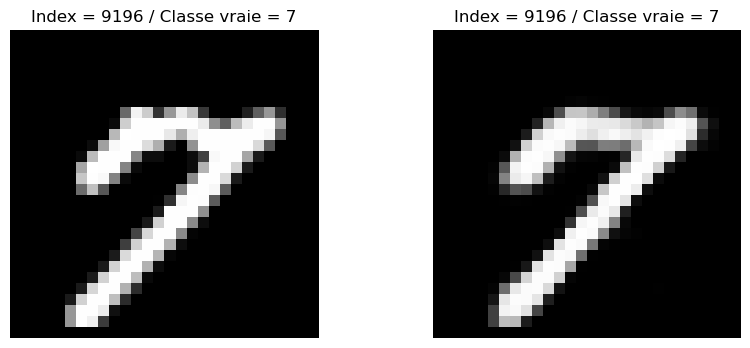

In [67]:
visualiser_autoencodeur(images_test, labels_test, X_reconstructed)

## Entraînement d'un auto-encodeur variationnel

In [70]:
class VariationalAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Le même encodeur que précédemment à l'exception de la dernière couche linéaire
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),            
            nn.Linear(128, 64),
            nn.ReLU()
        )
        # Cette dernière couche linéaire est remplacée par 2 couches qui vont fonctionner en parallèle (une bifurcation)
        # La première est pour la moyenne sur l'espace latent
        # La seconde est pour la variance sur l'espace latent
        self.mu = nn.Linear(64, 16)
        self.logvar = nn.Linear(64, 16)  # c'est en fait le logarithme de la variance, parce que c'est plus stable.

        # On finit par le même décodeur qu'avant
        self.decoder = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
        ) 

        # J'ai séparé la couche de sortie pour faciliter l'initialisation
        self.output = nn.Sequential(
            nn.Linear(256, 784),
            # nn.Sigmoid()
        )

    def reparametrize(self, mu, logvar):
        # Ici on vient échantilloner 1 point de la distribution que l'on essaie de construire, c'est ce que 
        # l'on passera ensuite au décodeur
        std = torch.exp(0.5 * logvar)  # std = sqrt(exp(logvar))
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Passage par l'encodeur
        h = self.encoder(x)
        # Gestion de l'espace latent
        mu = self.mu(h)
        logvar = self.logvar(h)
        z = self.reparametrize(mu, logvar)
        # Reconstruction avec le décodeur
        reconstructed = self.output(self.decoder(z))
        # Reconstructed servira pour l'erreur quadratique moyenne de construction
        # mu et logvar serviront pour calculer une pénalité liée à la divergence KL
        return reconstructed, mu, logvar

In [71]:
class AutoEncoderSigmoid(nn.Module):
    def forward(self, x):
        reconstructed, mu, logvar = x
        return F.sigmoid(reconstructed)

In [72]:
class BCEKLLoss(nn.Module):
    def __init__(self, beta=1):
        super().__init__()
        self.beta = beta
    
    def forward(self, outputs, targets):
        reconstructed, mu, logvar = outputs
        batch_size = targets.size(0) # Nombre d'images dans le mini-batch
        
        # Somme des pixels, puis moyenne sur le batch
        bce = F.binary_cross_entropy_with_logits(reconstructed, targets, reduction='sum') / batch_size
        
        # Somme des dimensions latentes, puis moyenne sur le batch
        kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / batch_size
        
        # L'équilibre mathématique d'origine est respecté
        return bce + self.beta * kl

In [73]:
model2 = VariationalAutoEncoder()
init_autoencoder(model2)

In [74]:
optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)
criterion = BCEKLLoss(beta=1)

In [75]:
# X_train = images_train.astype(np.float32)
# X_test = images_test.astype(np.float32)
# X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
# dataset = TensorDataset(X_train_tensor, X_train_tensor)
# train_loader = DataLoader(dataset, batch_size=256, shuffle=True)

In [76]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2 = model2.to(device)

In [77]:
fit_model(model2, train_loader, optimizer, criterion, epochs=100)

Époque [1/100] - Perte moyenne : 193.8757
Époque [10/100] - Perte moyenne : 109.4496
Époque [20/100] - Perte moyenne : 104.8109
Époque [30/100] - Perte moyenne : 102.6506
Époque [40/100] - Perte moyenne : 101.4702
Époque [50/100] - Perte moyenne : 100.5774
Époque [60/100] - Perte moyenne : 99.9444
Époque [70/100] - Perte moyenne : 99.4467
Époque [80/100] - Perte moyenne : 99.0663
Époque [90/100] - Perte moyenne : 98.7770
Époque [100/100] - Perte moyenne : 98.5396


In [78]:
model_inference2 = nn.Sequential(model2, AutoEncoderSigmoid())

In [79]:
model_inference2.eval()  # On passe le modèle en mode évaluation
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():  # Désactive le calcul des gradients
    X_reconstructed = model_inference2(X_test_tensor).cpu().numpy()

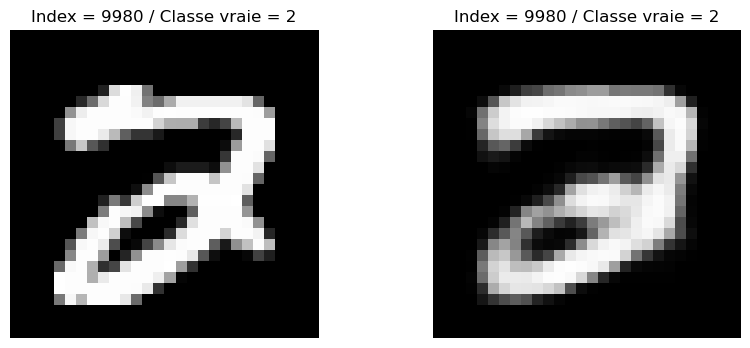

In [84]:
visualiser_autoencodeur(images_test, labels_test, X_reconstructed)

## Echantillonnage pour génération

In [85]:
model_gen2 = nn.Sequential(model2.decoder, model2.output, nn.Sigmoid())
model_gen2.eval();

In [186]:
mvnorm = sp.multivariate_normal(np.zeros(16), np.eye(16))

In [187]:
X_sample = mvnorm.rvs(1).reshape(1, -1).astype(np.float32)
# X_sample = np.array([0, -1]).reshape(-1, 2).astype(np.float32)

In [188]:
with torch.no_grad():
    X_gen = model_gen2(torch.as_tensor(X_sample)).cpu().numpy()

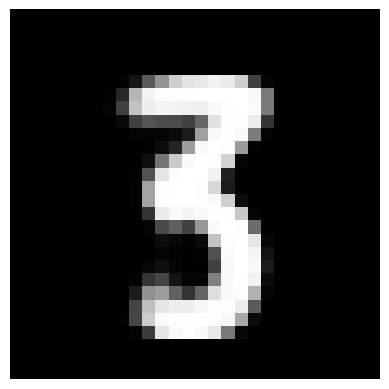

In [189]:
plt.imshow(X_gen.reshape((28, 28)), cmap="gray", vmin=0., vmax=1.)
plt.axis("off");